In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv("/content/Unemployment in India.csv")

In [3]:
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 768
Columns : 7


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [7]:
df = df.dropna()

print(df.shape)

(740, 7)


In [8]:
df.columns = [
    "Region",
    "Date",
    "Frequency",
    "Estimated_Unemployment_Rate",
    "Estimated_Employed",
    "Labour_Participation_Rate",
    "Area"
]

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

/tmp/ipykernel_2289/936118274.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])
/tmp/ipykernel_2289/936118274.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date"] = pd.to_datetime(df["Date"])


In [10]:
df.dtypes

,0
Region,object
Date,datetime64[ns]
Frequency,object
Estimated_Unemployment_Rate,float64
Estimated_Employed,float64
Labour_Participation_Rate,float64
Area,object


In [11]:
df.describe()

,Date,Estimated_Unemployment_Rate,Estimated_Employed,Labour_Participation_Rate
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [12]:
print(df["Region"].nunique())
print(df["Region"].unique())

28
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']


In [13]:
df["Month"] = df["Date"].dt.month_name()

/tmp/ipykernel_2289/1782983683.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Month"] = df["Date"].dt.month_name()


In [14]:
df["Year"] = df["Date"].dt.year

/tmp/ipykernel_2289/437350127.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Year"] = df["Date"].dt.year


In [15]:
region_avg = (
    df.groupby("Region")["Estimated_Unemployment_Rate"]
      .mean()
      .sort_values(ascending=False)
)

region_avg.head()

,Estimated_Unemployment_Rate
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357


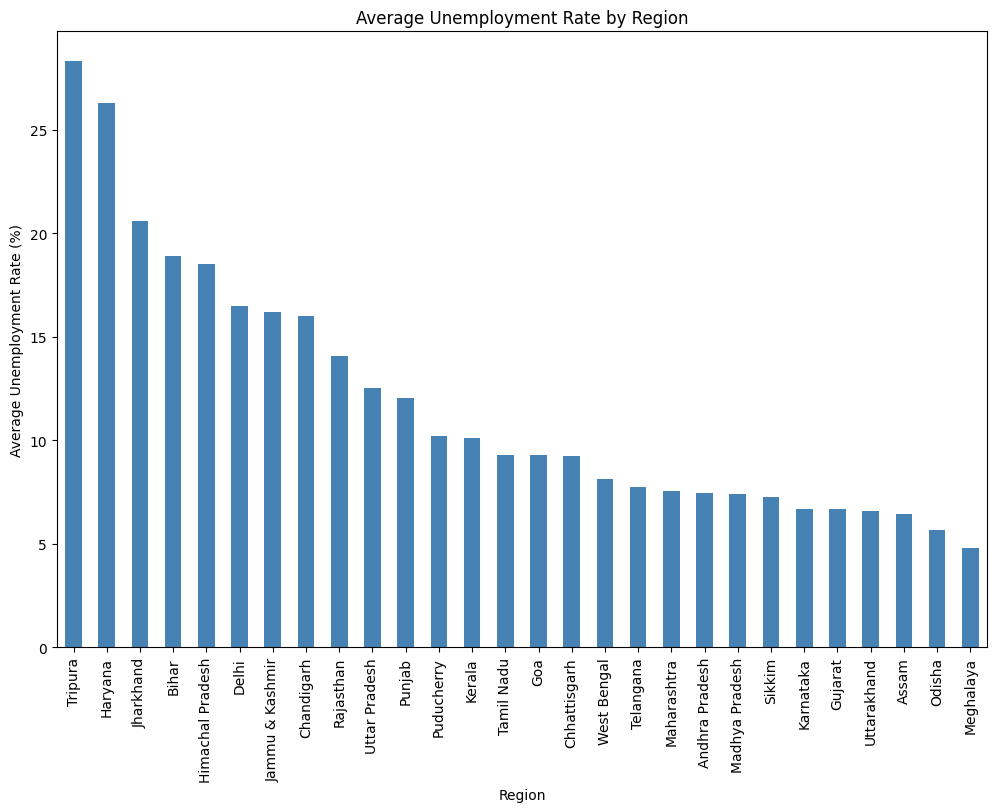

In [16]:
plt.figure(figsize=(12,8))

region_avg.plot(kind="bar", color="steelblue")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)

plt.show()

In [17]:
monthly = (
    df.groupby("Month")["Estimated_Unemployment_Rate"]
      .mean()
)

In [18]:
month_order = [
'January','February','March','April','May','June',
'July','August','September','October','November','December'
]

monthly = monthly.reindex(month_order)

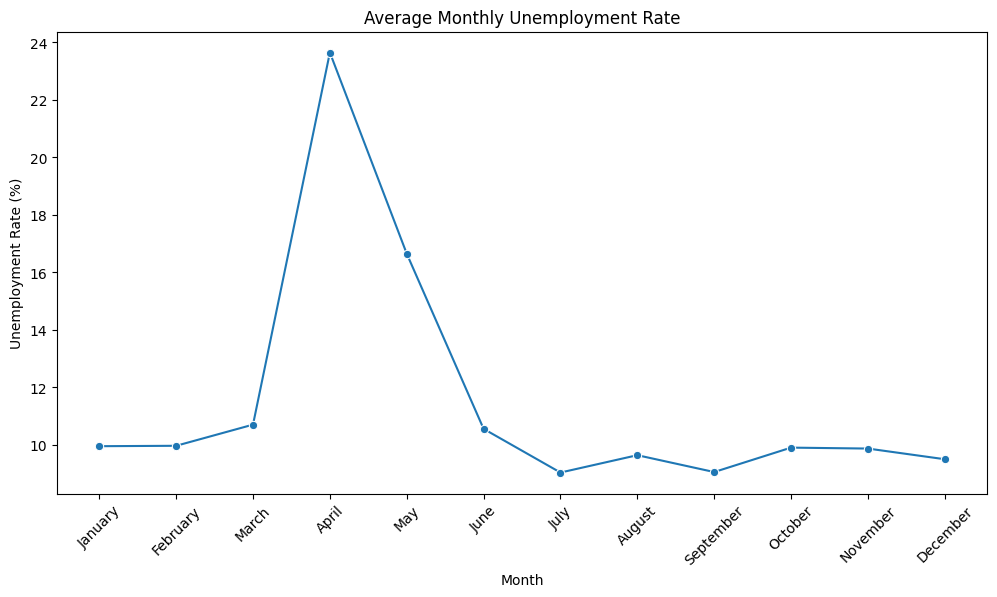

In [19]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Average Monthly Unemployment Rate")

plt.xlabel("Month")

plt.ylabel("Unemployment Rate (%)")

plt.show()

In [20]:
states = [
    "Kerala",
    "Maharashtra",
    "Tamil Nadu"
]

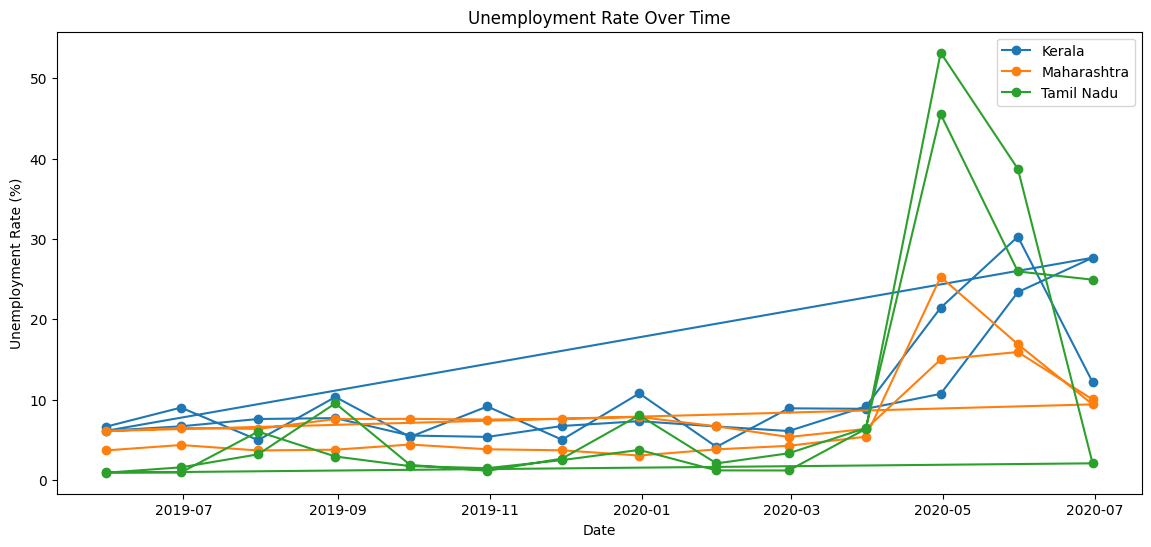

In [21]:
plt.figure(figsize=(14,6))

for state in states:

    temp = df[df["Region"]==state]

    plt.plot(
        temp["Date"],
        temp["Estimated_Unemployment_Rate"],
        marker="o",
        label=state
    )

plt.legend()

plt.title("Unemployment Rate Over Time")

plt.xlabel("Date")

plt.ylabel("Unemployment Rate (%)")

plt.show()

In [22]:
top10 = region_avg.head(10)

/tmp/ipykernel_2289/1434273517.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


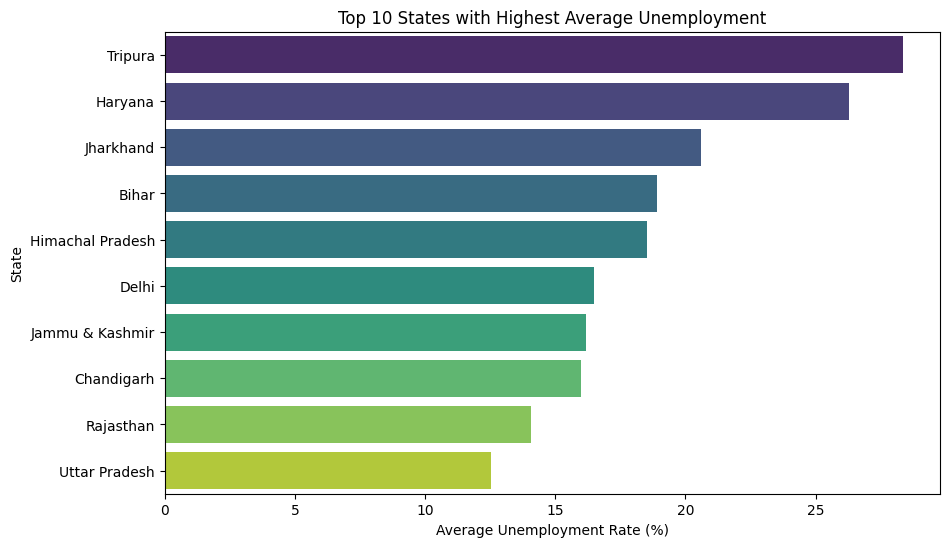

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette="viridis"
)

plt.title("Top 10 States with Highest Average Unemployment")

plt.xlabel("Average Unemployment Rate (%)")

plt.ylabel("State")

plt.show()

In [24]:
corr = df[
[
"Estimated_Unemployment_Rate",
"Estimated_Employed",
"Labour_Participation_Rate"
]
].corr()

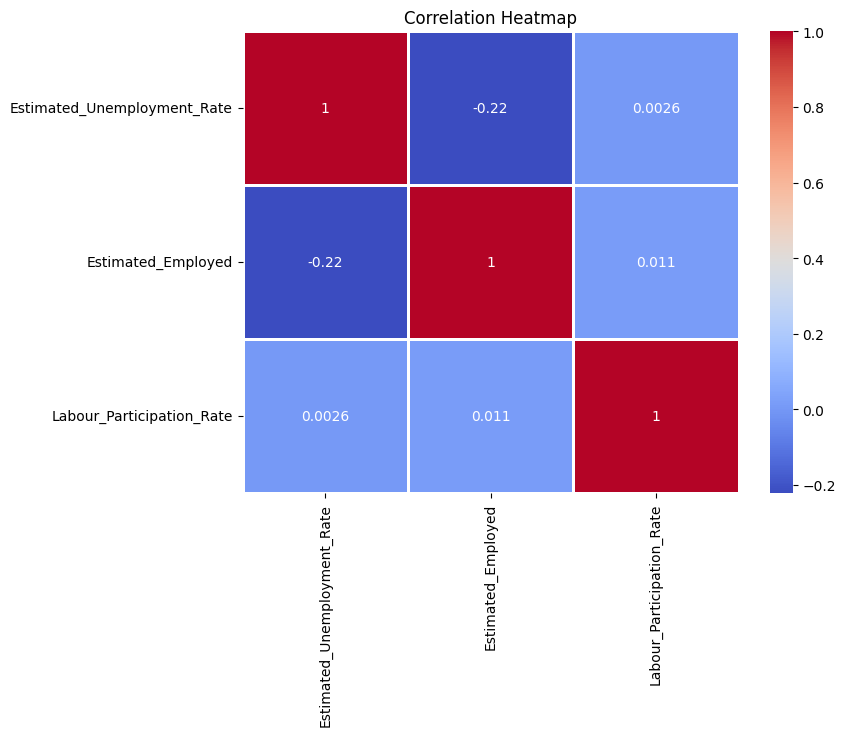

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=1
)

plt.title("Correlation Heatmap")

plt.show()

In [26]:
covid_date = pd.Timestamp("2020-03-25")

pre = df[df["Date"] < covid_date]

post = df[df["Date"] >= covid_date]

In [ ]:
print("Pre-COVID Mean")

print(pre["Estimated_Unemployment_Rate"].mean())

print()

print("Post-COVID Mean")

print(post["Estimated_Unemployment_Rate"].mean())

In [ ]:
comparison = pd.DataFrame({

"Period":["Pre COVID","Post COVID"],

"Average Unemployment":[

pre["Estimated_Unemployment_Rate"].mean(),

post["Estimated_Unemployment_Rate"].mean()

]

})

comparison

In [ ]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment",
    palette=["green","red"]
)

plt.title("Pre vs Post COVID Unemployment Rate")

plt.show()